IndexError: index 70 is out of bounds for axis 0 with size 70

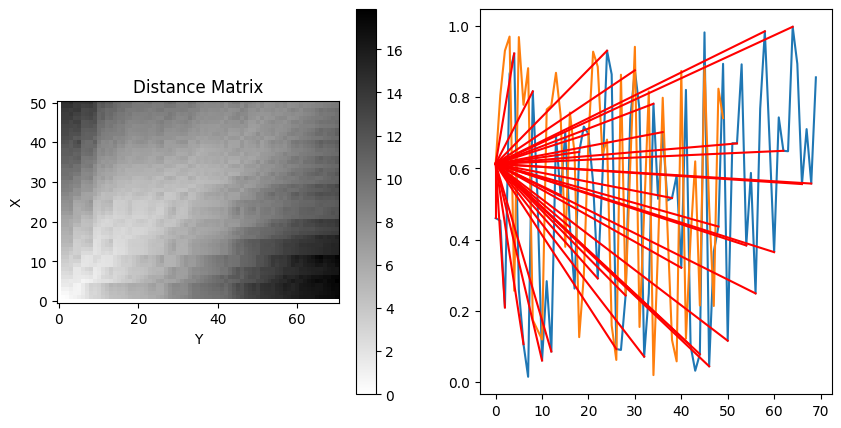

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def euclidean_distance(x, y):
    return np.sqrt(np.sum((x-y)**2))

def dtw_distance(x, y, dist_func):
    n = len(x)
    m = len(y)
    D = np.zeros((n+1, m+1))
    D[0,1:] = np.inf
    D[1:,0] = np.inf
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = dist_func(x[i-1], y[j-1])
            D[i,j] = cost + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
    return D[n,m], D

# Generate two random time series
x = np.random.rand(50)
y = np.random.rand(70)

# Compute the DTW distance between the time series using the Euclidean distance
dist, D = dtw_distance(x, y, euclidean_distance)

# Plot the distance matrix and the optimal path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

# Plot the distance matrix
im = ax1.imshow(D, cmap='gray_r', origin='lower')
ax1.set_title('Distance Matrix')
ax1.set_xlabel('Y')
ax1.set_ylabel('X')
plt.colorbar(im, ax=ax1)

# Plot the optimal path
n, m = D.shape
path = [(i, j) for i, j in zip(*np.where(np.ones((n, m)))) if (i+j)%2 == 0]
ax2.plot(y, label='Y')
ax2.plot(x, label='X')
for i, j in path:
    ax2.plot([i, j], [x[i], y[j]], color='r')
ax2.set_title('Optimal Path')
ax2.legend()
plt.show()

In [3]:
D.shape

(51, 71)